# Iris Flower Classification using Machine Learning

**Topic:** Iris Flower Classification  
**Dataset Link:** [Kaggle Iris Flower Dataset](https://www.kaggle.com/datasets/arshid/iris-flower-dataset)

## Project Objective
The objective of this project is to build a Machine Learning model that can classify iris flowers into one of three species:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The prediction is based on four flower measurements:

- Sepal length
- Sepal width
- Petal length
- Petal width


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings('ignore')

## 2. Load the Dataset

Download the dataset from Kaggle:

[https://www.kaggle.com/datasets/arshid/iris-flower-dataset](https://www.kaggle.com/datasets/arshid/iris-flower-dataset)

After downloading, place the CSV file in the same folder as this notebook.

Common file name: `IRIS.csv`


In [3]:
# Load dataset
# Make sure IRIS.csv is in the same folder as this notebook

df = pd.read_csv('IRIS.csv')

# Display first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## 3. Basic Dataset Information

In [4]:
# Shape of dataset
print('Rows and Columns:', df.shape)

Rows and Columns: (150, 5)


In [5]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [6]:
# Statistical summary
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [7]:
# Check column names
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

## 4. Check for Missing Values

In [8]:
df.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

## 5. Check Target Classes

In [9]:
df['species'].value_counts()

species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

## 6. Exploratory Data Analysis

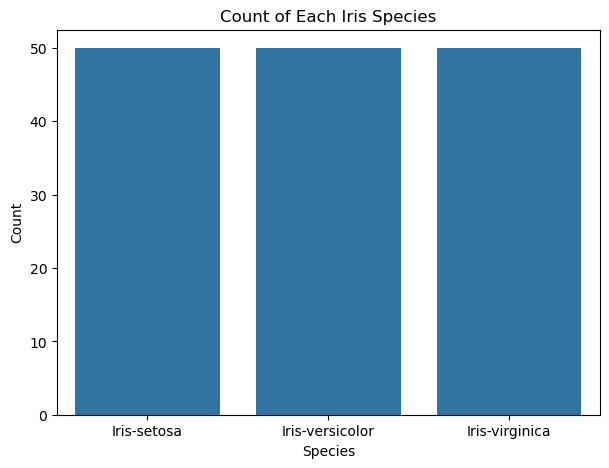

In [10]:
plt.figure(figsize=(7,5))
sns.countplot(x='species', data=df)
plt.title('Count of Each Iris Species')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

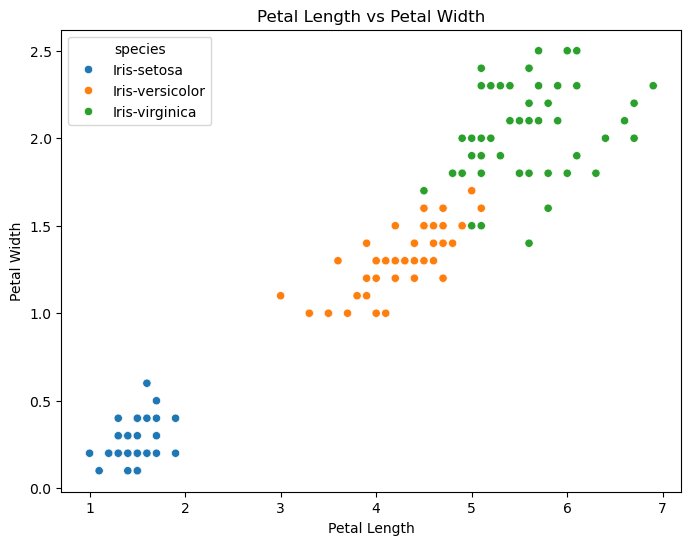

In [11]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='petal_length', y='petal_width', hue='species', data=df)
plt.title('Petal Length vs Petal Width')
plt.xlabel('Petal Length')
plt.ylabel('Petal Width')
plt.show()

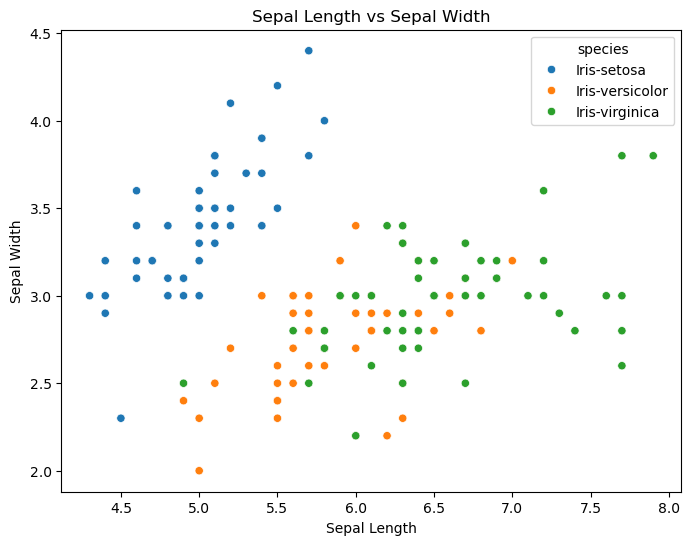

In [12]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='sepal_length', y='sepal_width', hue='species', data=df)
plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.show()

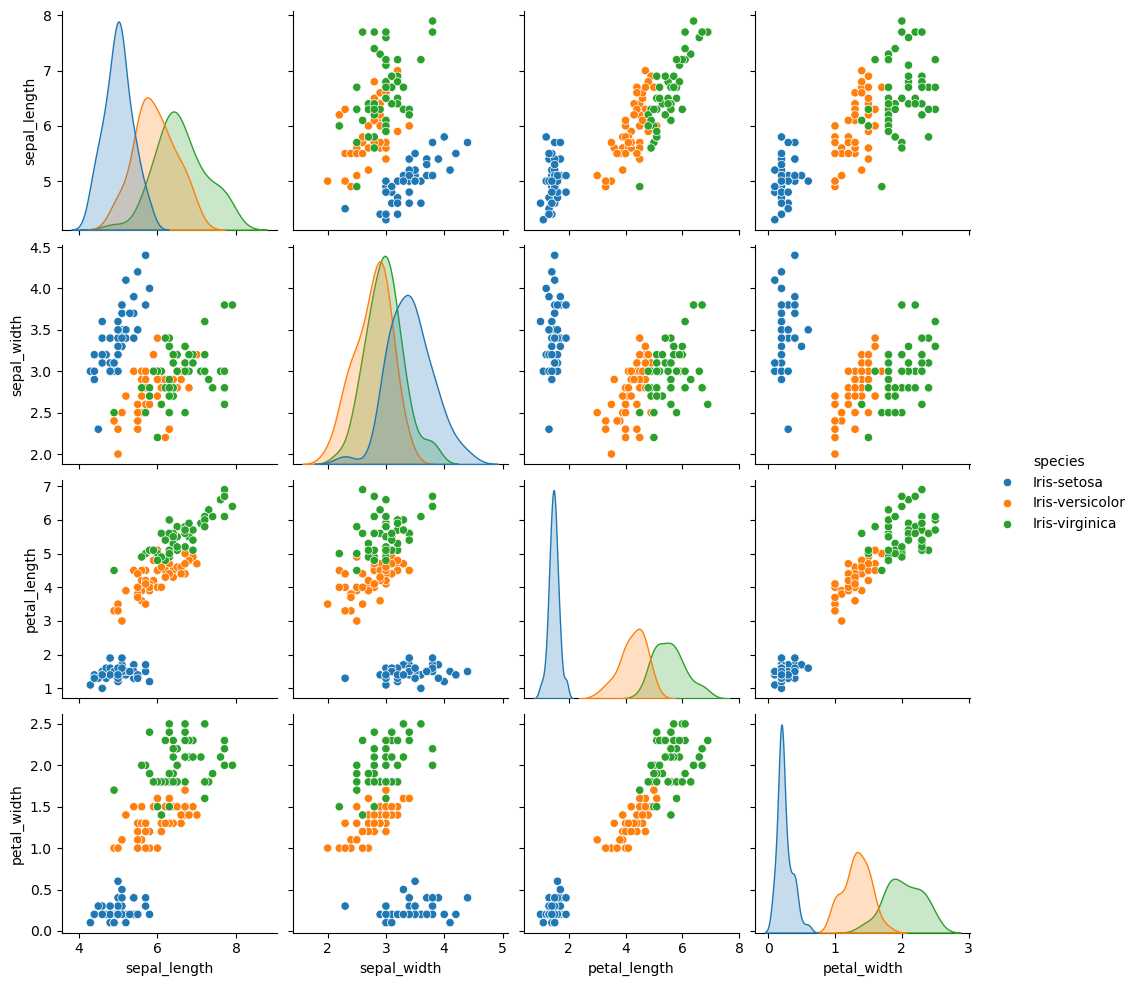

In [13]:
sns.pairplot(df, hue='species')
plt.show()

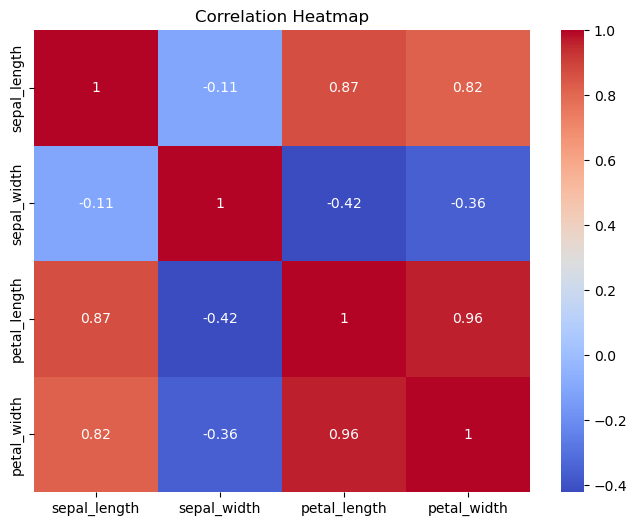

In [14]:
plt.figure(figsize=(8,6))
sns.heatmap(df.drop('species', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 7. Prepare Data for Machine Learning

In [15]:
# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (150, 4)
Target shape: (150,)


In [16]:
# Encode target labels
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print('Classes:', encoder.classes_)
print('Encoded labels:', np.unique(y_encoded))

Classes: ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']
Encoded labels: [0 1 2]


In [17]:
# Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42
)

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape:', y_test.shape)

X_train shape: (120, 4)
X_test shape: (30, 4)
y_train shape: (120,)
y_test shape: (30,)


## 8. Train Multiple Machine Learning Models

In [18]:
models = {
    'Logistic Regression': LogisticRegression(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=3),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42)
}

results = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[model_name] = accuracy
    print(model_name, 'Accuracy:', round(accuracy * 100, 2), '%')

Logistic Regression Accuracy: 100.0 %
K-Nearest Neighbors Accuracy: 100.0 %
Decision Tree Accuracy: 100.0 %
Random Forest Accuracy: 100.0 %


## 9. Compare Model Accuracy

In [19]:
results_df = pd.DataFrame({
    'Model': results.keys(),
    'Accuracy': results.values()
})

results_df

,Model,Accuracy
0,Logistic Regression,1.0
1,K-Nearest Neighbors,1.0
2,Decision Tree,1.0
3,Random Forest,1.0


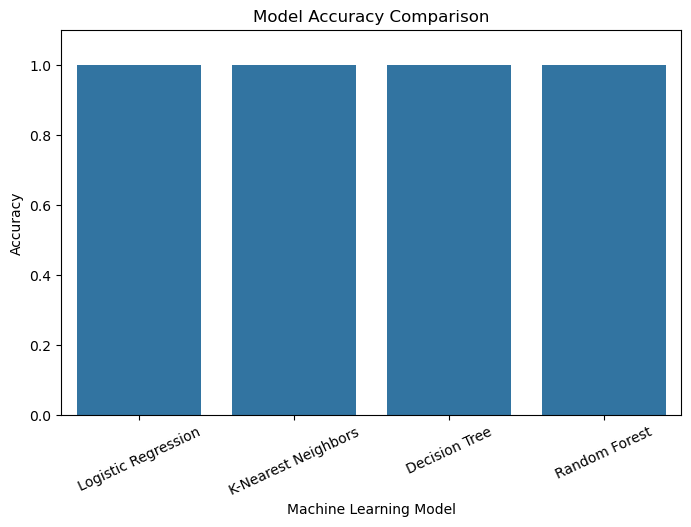

In [20]:
plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results_df)
plt.title('Model Accuracy Comparison')
plt.xlabel('Machine Learning Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=25)
plt.ylim(0, 1.1)
plt.show()

## 10. Select Best Model

Here we select the model with the highest accuracy.


In [21]:
best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print('Best Model:', best_model_name)
print('Best Accuracy:', round(results[best_model_name] * 100, 2), '%')

Best Model: Logistic Regression
Best Accuracy: 100.0 %


## 11. Evaluation of Best Model

In [22]:
y_pred_best = best_model.predict(X_test)

print('Classification Report:')
print(classification_report(y_test, y_pred_best, target_names=encoder.classes_))

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



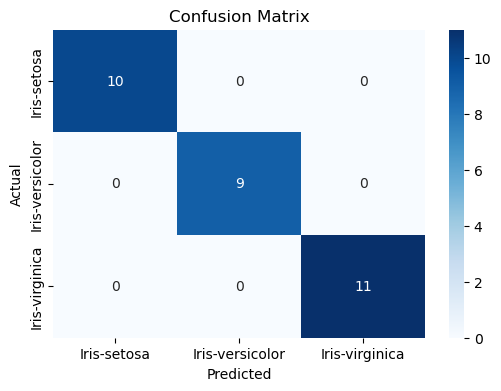

In [23]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 12. Make Prediction on New Data

Example flower measurements:

- Sepal length = 5.1
- Sepal width = 3.5
- Petal length = 1.4
- Petal width = 0.2


In [24]:
# New sample data
new_flower = pd.DataFrame({
    'sepal_length': [5.1],
    'sepal_width': [3.5],
    'petal_length': [1.4],
    'petal_width': [0.2]
})

prediction = best_model.predict(new_flower)
predicted_species = encoder.inverse_transform(prediction)

print('Predicted Iris Species:', predicted_species[0])

Predicted Iris Species: Iris-setosa


## 13. Conclusion

In this project, we successfully built a Machine Learning model to classify iris flowers into three species using flower measurements.

### Steps performed:

1. Loaded the Iris dataset
2. Explored and visualized the data
3. Prepared features and target variable
4. Trained multiple ML models
5. Compared model accuracy
6. Evaluated the best model
7. Predicted species for new flower data

### Final Result
The best-performing model can classify iris flowers accurately based on sepal and petal measurements.
